<a href="https://colab.research.google.com/github/RafaXzaviero/BENGKEL-KODING/blob/main/Airline_Passenger_Satisfaction_RafaelA11_2023_15146.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## MEMBACA DATASET CSV DARI DIRECTORY

In [2]:
import pandas as pd

df = pd.read_csv('/content/airline_passenger_satisfaction.csv')
display(df.head())

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,Male,48,First-time,Business,Business,821,2,5.0,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,Female,35,Returning,Business,Business,821,26,39.0,2,...,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853,0,0.0,4,...,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,Business,Business,1905,0,0.0,2,...,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,Returning,Business,Business,3470,0,1.0,3,...,3,4,4,5,4,3,3,3,3,Satisfied


## 1. Explorasi Data (EDA)

In [3]:
print('Jumlah Missing Values per Kolom:')
display(df.isnull().sum())
print('\nPersentase Missing Values per Kolom:')
display(df.isnull().sum() / len(df) * 100)

Jumlah Missing Values per Kolom:


,0
ID,0
Gender,0
Age,0
Customer Type,0
Type of Travel,0
Class,0
Flight Distance,0
Departure Delay,0
Arrival Delay,393
Departure and Arrival Time Convenience,0



Persentase Missing Values per Kolom:


,0
ID,0.000000
Gender,0.000000
Age,0.000000
Customer Type,0.000000
Type of Travel,0.000000
Class,0.000000
Flight Distance,0.000000
Departure Delay,0.000000
Arrival Delay,0.302587
Departure and Arrival Time Convenience,0.000000


In [4]:
print('\nStatistik Deskriptif untuk Kolom Numerik:')
display(df[['Age', 'Flight Distance', 'Departure Delay', 'Arrival Delay']].describe())


Statistik Deskriptif untuk Kolom Numerik:


,Age,Flight Distance,Departure Delay,Arrival Delay
count,129880.000000,129880.000000,129880.000000,129487.000000
mean,39.427957,1190.316392,14.713713,15.091129
std,15.119360,997.452477,38.071126,38.465650
min,7.000000,31.000000,0.000000,0.000000
25%,27.000000,414.000000,0.000000,0.000000
50%,40.000000,844.000000,0.000000,0.000000
75%,51.000000,1744.000000,12.000000,13.000000
max,85.000000,4983.000000,1592.000000,1584.000000


In [5]:
print(f'Jumlah data duplikat: {df.duplicated().sum()}')

Jumlah data duplikat: 0


### 1.1 Identifikasi & Pengelompokan Fitur

Berdasarkan `df.info()` dan pemahaman data, fitur-fitur dapat dikelompokkan sebagai berikut:

*   **Fitur Kategorikal:** Merupakan fitur nominal yang nilainya tidak memiliki urutan atau tingkatan.
    *   `Gender` (Male, Female)
    *   `Customer Type` (Returning, First-time)
    *   `Type of Travel` (Business, Personal)
    *   `Class` (Business, Economy, Economy Plus)
    *   `Satisfaction` (Neutral or Dissatisfied, Satisfied) - *Ini adalah variabel target*

*   **Fitur Kontinu (Numerik):** Merupakan fitur kuantitatif yang nilainya dapat berupa bilangan riil dalam rentang tertentu.
    *   `Age`
    *   `Flight Distance`
    *   `Departure Delay`
    *   `Arrival Delay`

*   **Fitur Rating (Ordinal):** Merupakan fitur kategori yang nilainya memiliki urutan atau tingkatan (misalnya, skala 1-5).
    *   `Departure and Arrival Time Convenience`
    *   `Ease of Online Booking`
    *   `Check-in Service`
    *   `Online Boarding`
    *   `Gate Location`
    *   `On-board Service`
    *   `Seat Comfort`
    *   `Leg Room Service`
    *   `Cleanliness`
    *   `Food and Drink`
    *   `In-flight Service`
    *   `In-flight Wifi Service`
    *   `In-flight Entertainment`
    *   `Baggage Handling`

### 1.3.1 Visualisasi Distribusi Variabel Target (Satisfaction)

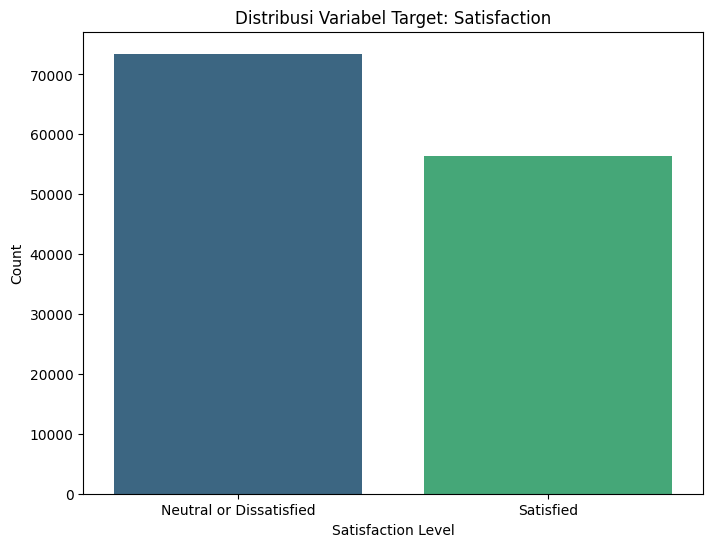


Persentase Distribusi Variabel Target:


,proportion
Satisfaction,
Neutral or Dissatisfied,56.553742
Satisfied,43.446258


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Satisfaction', palette='viridis', hue='Satisfaction', legend=False)
plt.title('Distribusi Variabel Target: Satisfaction')
plt.xlabel('Satisfaction Level')
plt.ylabel('Count')
plt.show()

print('\nPersentase Distribusi Variabel Target:')
display(df['Satisfaction'].value_counts(normalize=True) * 100)

#### Penjelasan Imbalance Class

Dari visualisasi distribusi variabel target (Satisfaction) di atas, terlihat bahwa jumlah penumpang yang `Neutral or Dissatisfied` lebih banyak dibandingkan dengan yang `Satisfied`. Hal ini mengindikasikan adanya _class imbalance_. Ini penting untuk diperhatikan dalam fase pemodelan karena model cenderung berkinerja lebih baik pada kelas mayoritas dan mungkin kurang baik dalam memprediksi kelas minoritas.

Persentase:
*   Neutral or Dissatisfied: `{{df['Satisfaction'].value_counts(normalize=True).loc['Neutral or Dissatisfied'] * 100:.2f}}%`
*   Satisfied: `{{df['Satisfaction'].value_counts(normalize=True).loc['Satisfied'] * 100:.2f}}%`

### 1.3.2 Visualisasi Distribusi Fitur Kategorikal

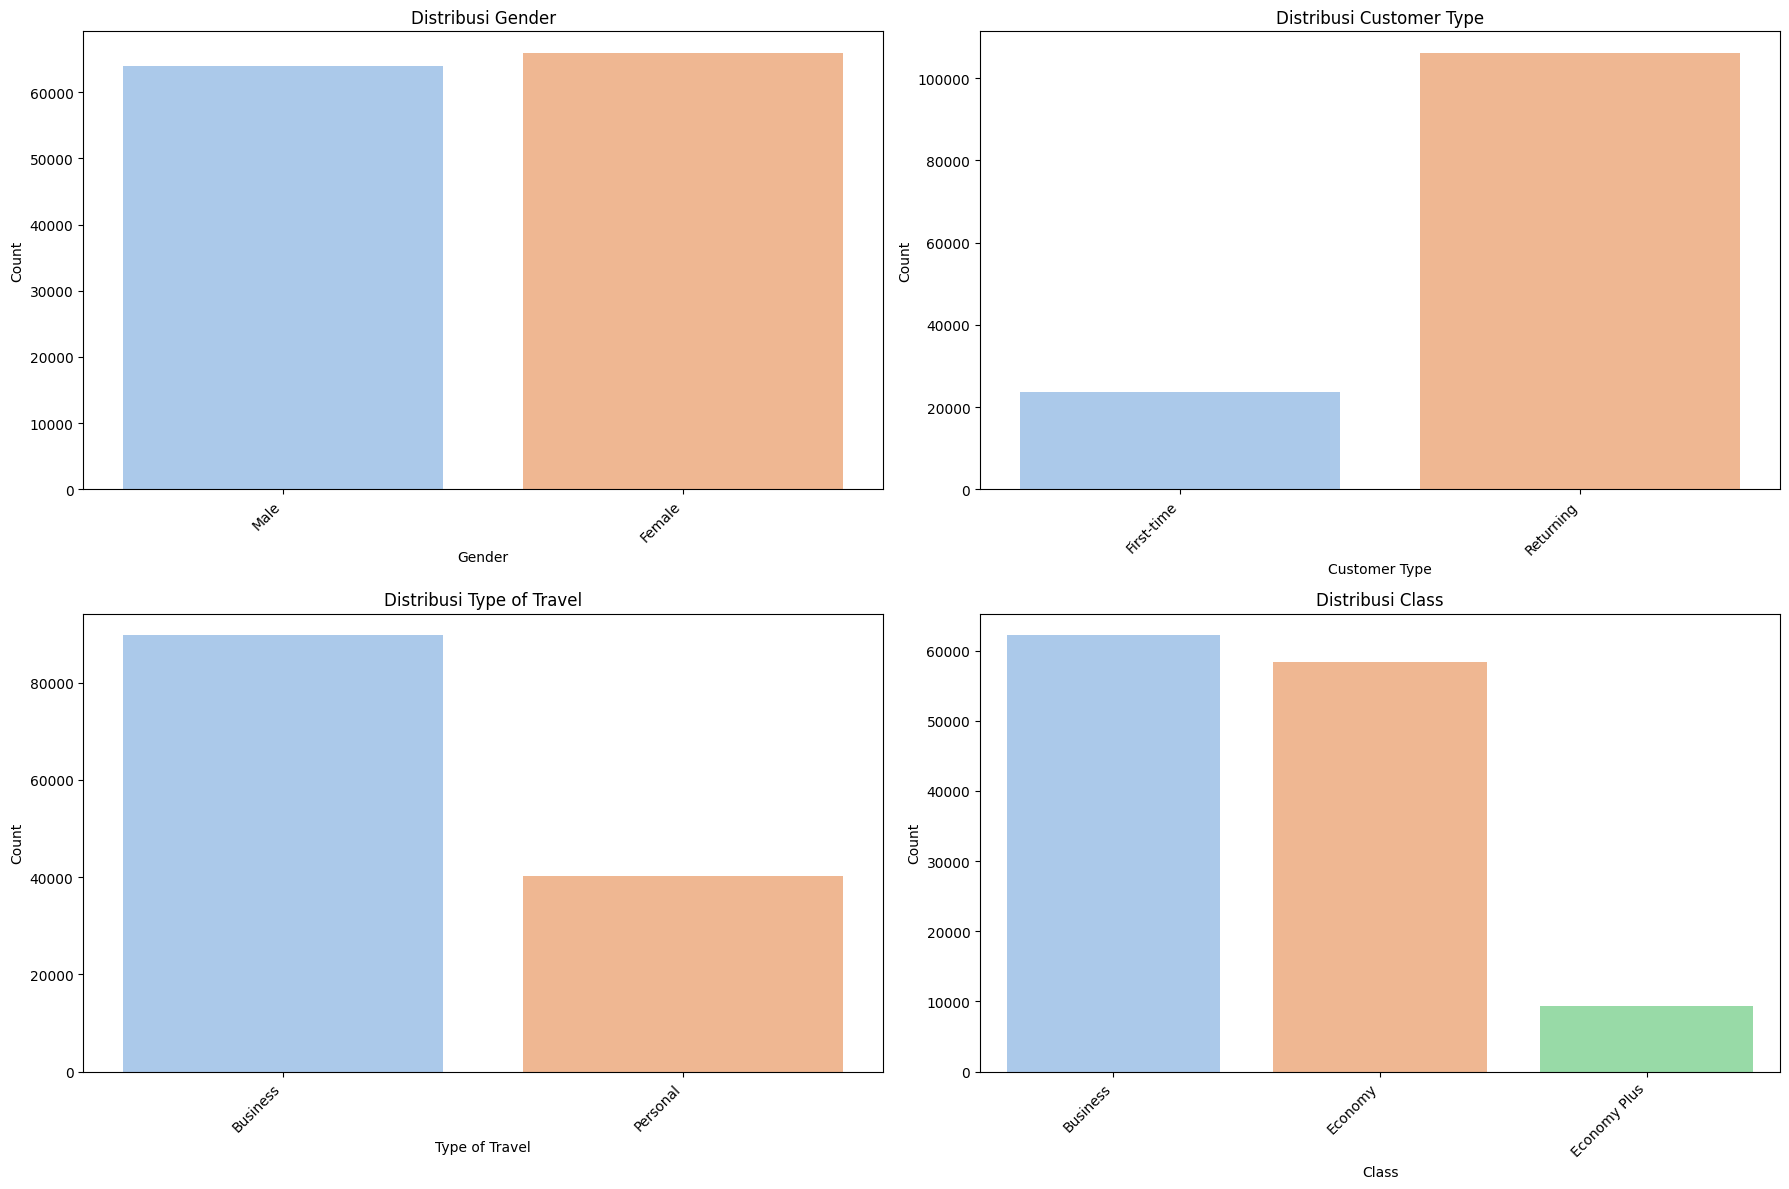

In [7]:
categorical_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']

plt.figure(figsize=(18, 12))
for i, col in enumerate(categorical_cols):
    plt.subplot(2, 2, i + 1)
    sns.countplot(data=df, x=col, palette='pastel', hue=col, legend=False)
    plt.title(f'Distribusi {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 1.3.3 Visualisasi Distribusi Fitur Rating (Ordinal)

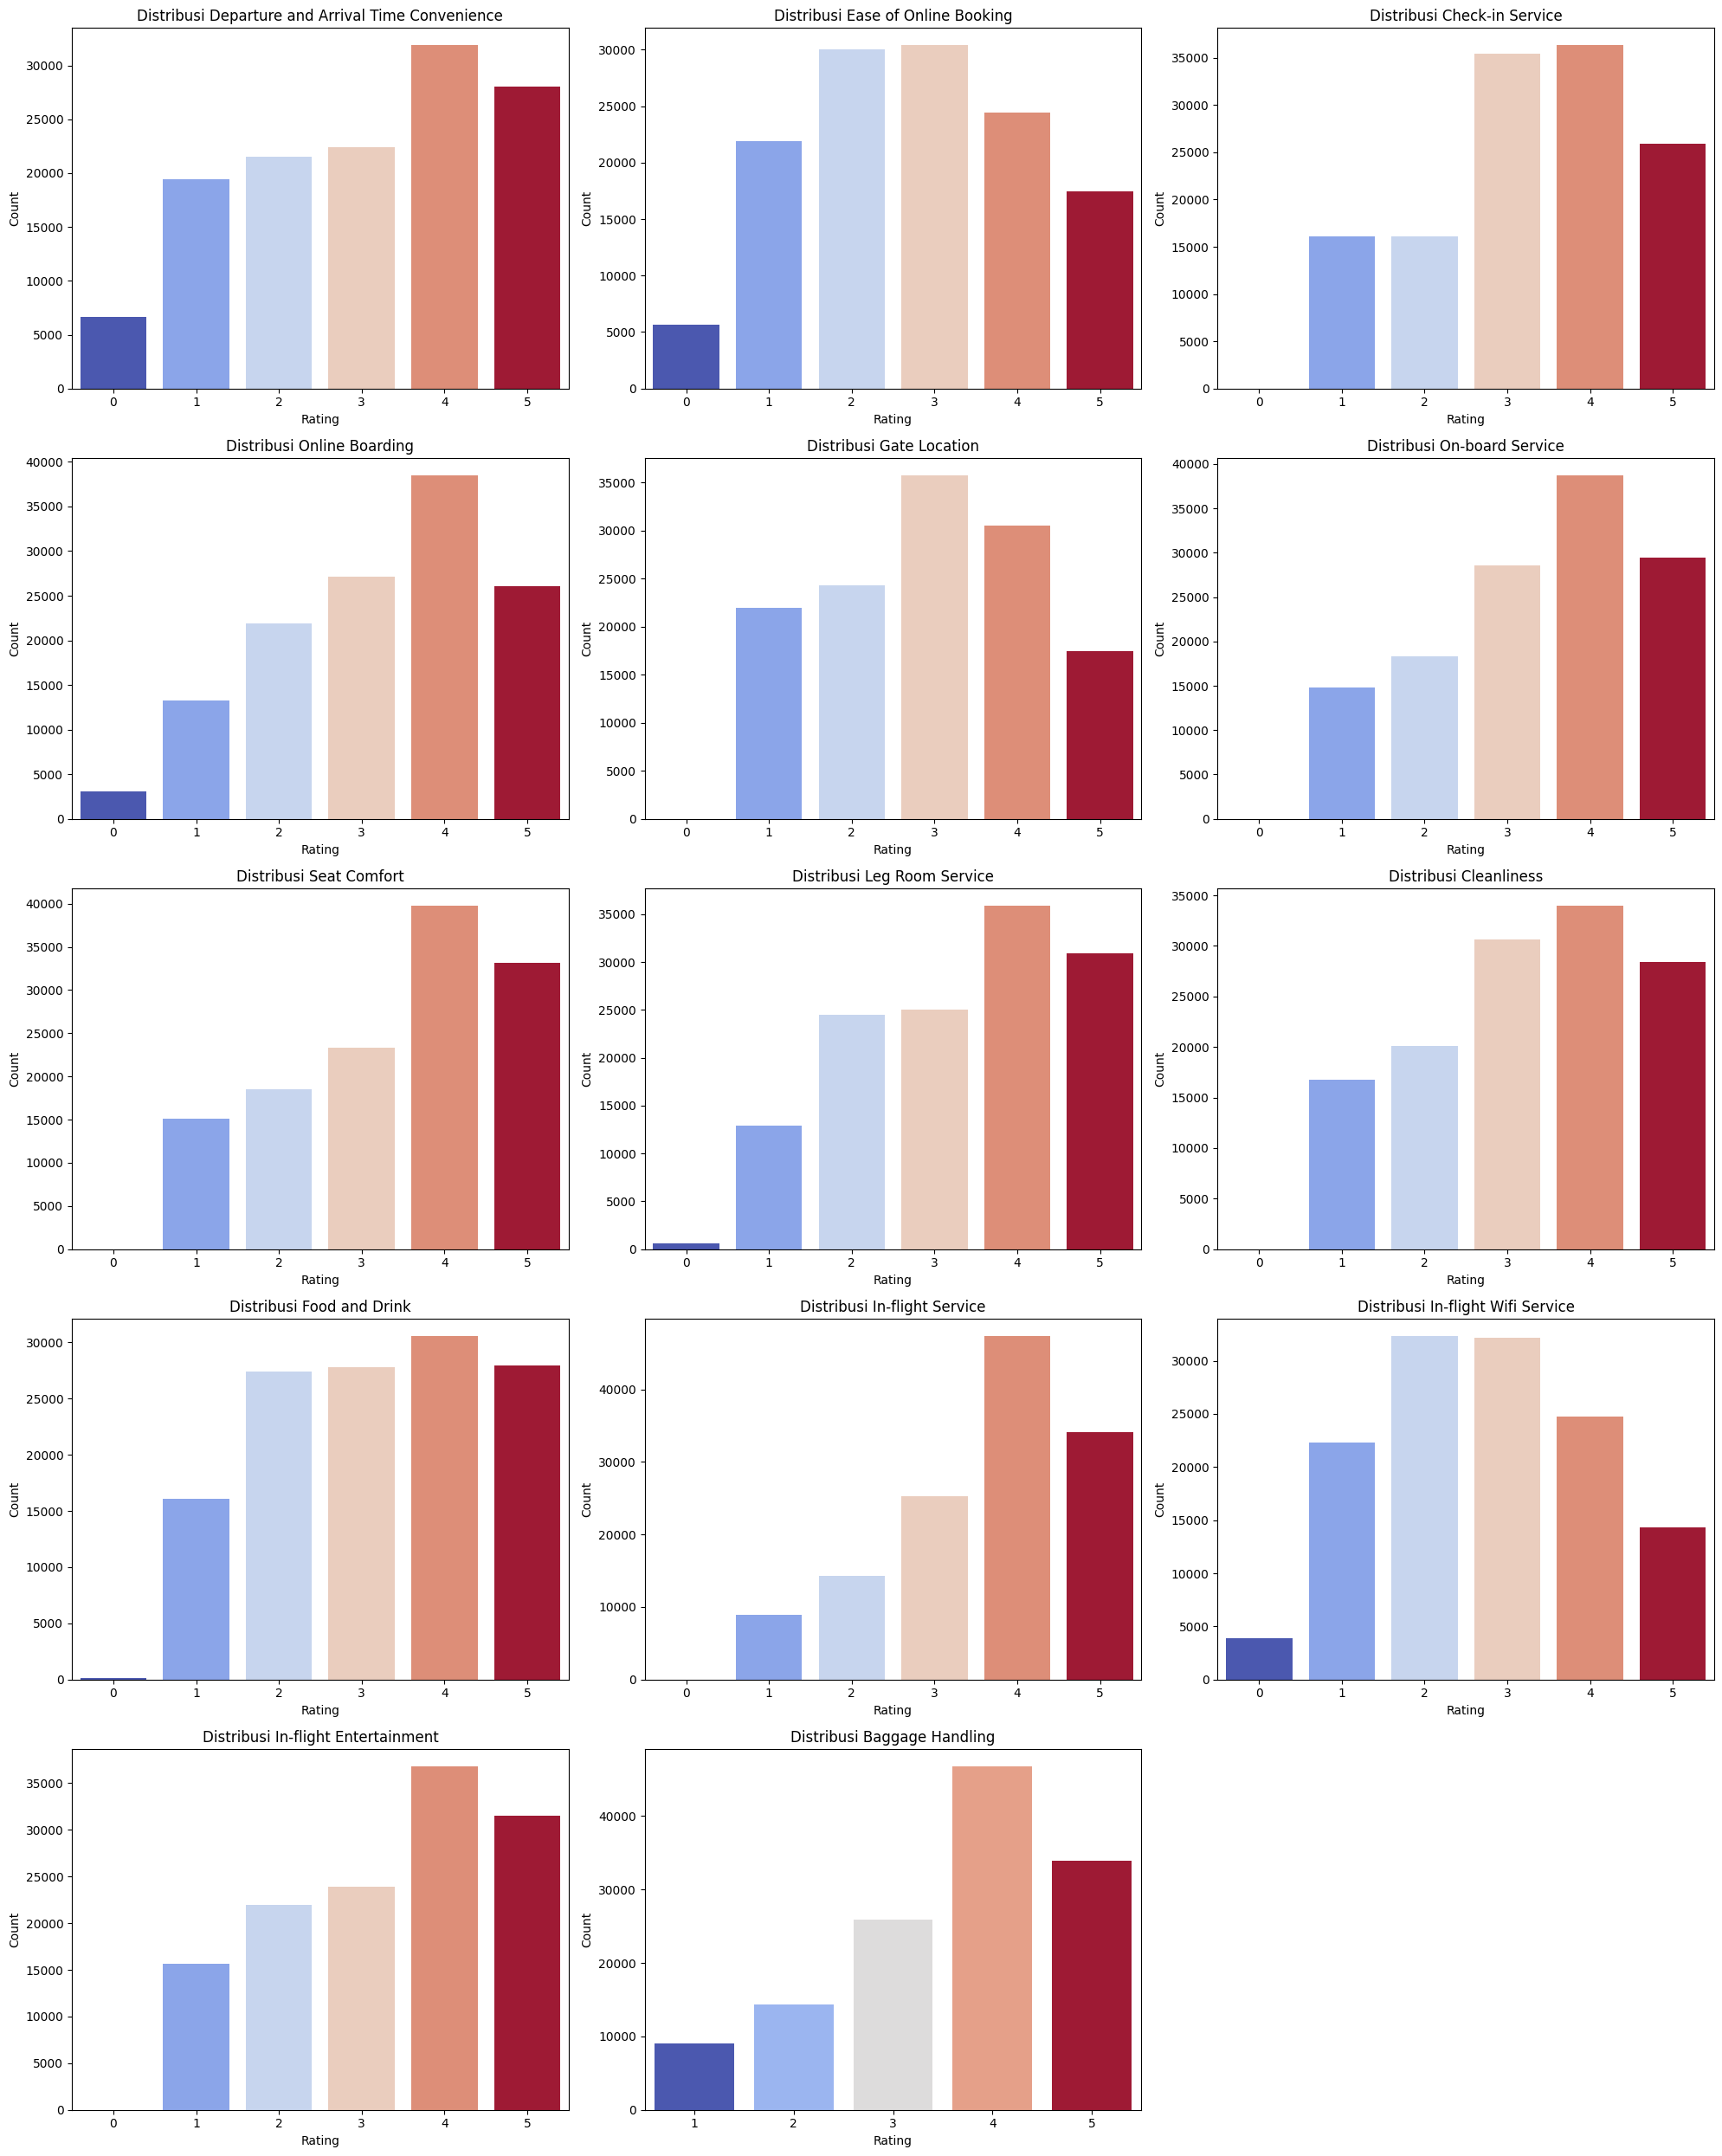

In [8]:
rating_cols = [
    'Departure and Arrival Time Convenience', 'Ease of Online Booking',
    'Check-in Service', 'Online Boarding', 'Gate Location', 'On-board Service',
    'Seat Comfort', 'Leg Room Service', 'Cleanliness', 'Food and Drink',
    'In-flight Service', 'In-flight Wifi Service', 'In-flight Entertainment',
    'Baggage Handling'
]

plt.figure(figsize=(20, 25))
for i, col in enumerate(rating_cols):
    plt.subplot(5, 3, i + 1) # Adjust subplot grid based on number of rating cols
    sns.countplot(data=df, x=col, palette='coolwarm', hue=col, legend=False)
    plt.title(f'Distribusi {col}')
    plt.xlabel('Rating')
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 1.4 Analisis Outlier & Korelasi

## 1.4.1 Deteksi Outlier pada Fitur Kontinu (Boxplot)

/tmp/ipykernel_2259/1288428726.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[col], palette='viridis') # `hue` parameter removed
/tmp/ipykernel_2259/1288428726.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[col], palette='viridis') # `hue` parameter removed
/tmp/ipykernel_2259/1288428726.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[col], palette='viridis') # `hue` parameter removed
/tmp/ipykernel_2259/1288428726.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed 

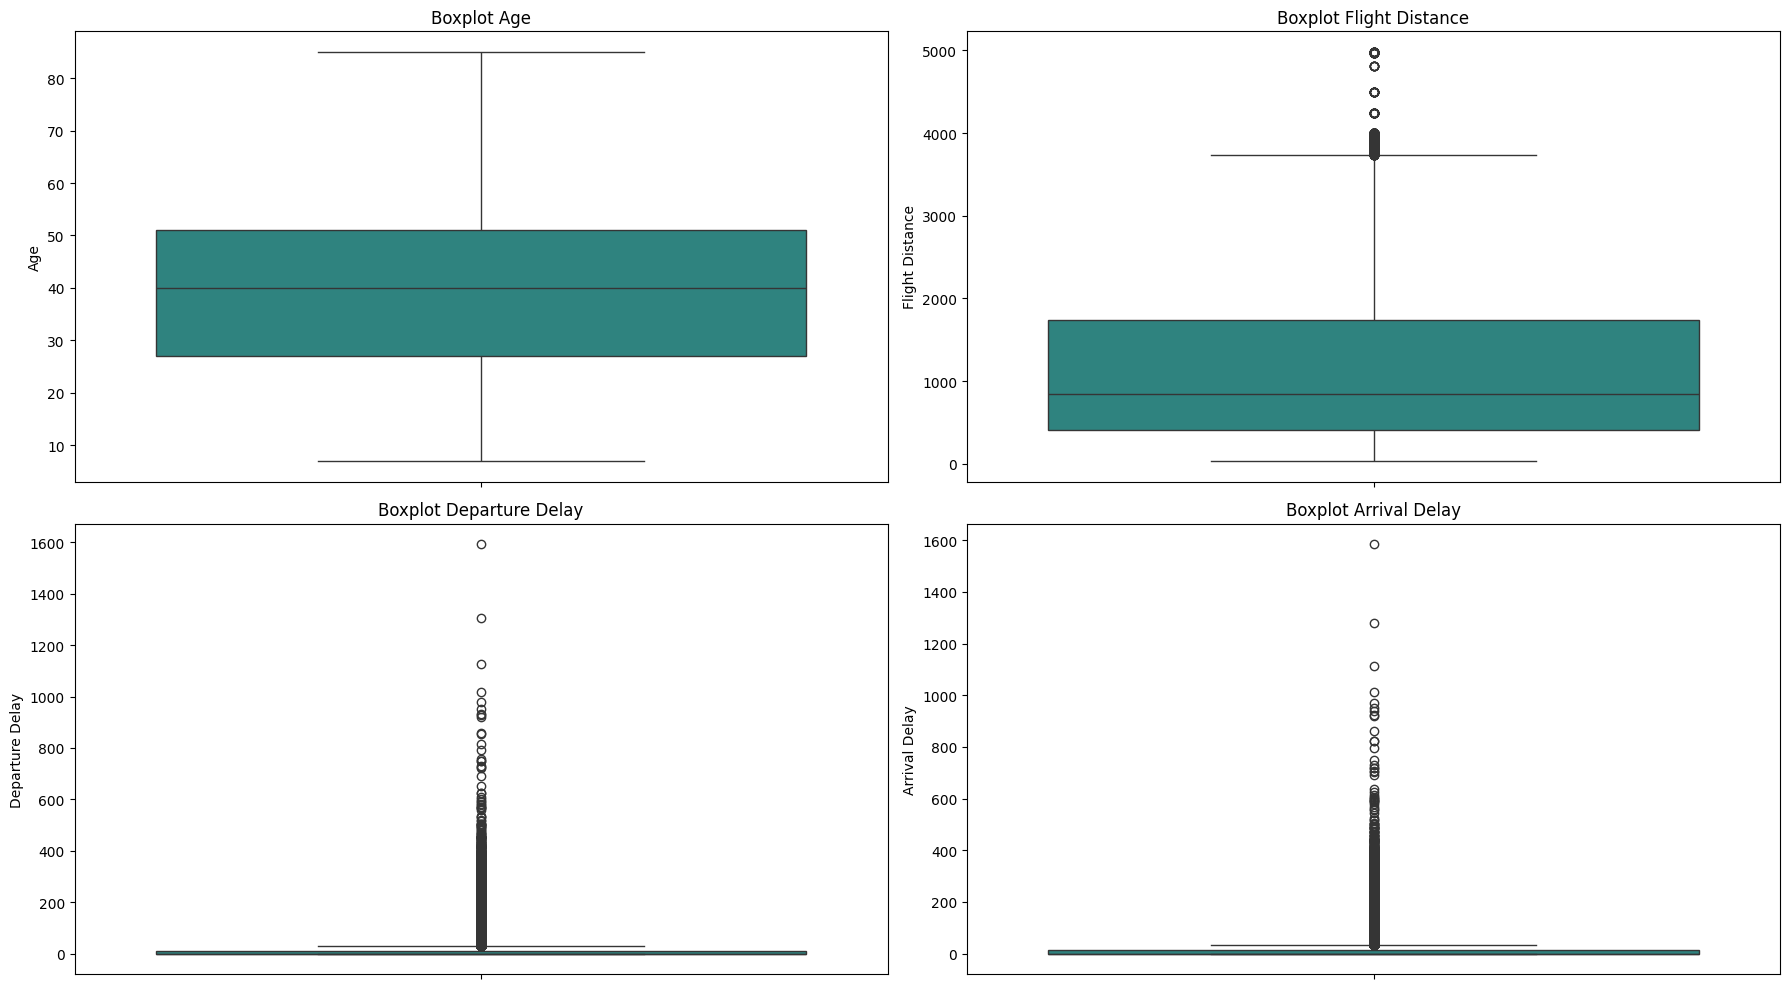

In [9]:
numerical_cols = ['Age', 'Flight Distance', 'Departure Delay', 'Arrival Delay']

plt.figure(figsize=(18, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(y=df[col], palette='viridis') # `hue` parameter removed
    plt.title(f'Boxplot {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

#### Penjelasan Outlier

Dari boxplot di atas:

*   **Age:** Terlihat bahwa distribusi usia cukup merata dan tidak memiliki outlier yang signifikan. Ini menunjukkan data usia cukup bersih.
*   **Flight Distance:** Terdapat beberapa outlier pada nilai jarak penerbangan yang sangat tinggi. Ini wajar karena ada penerbangan jarak sangat jauh yang mungkin jarang terjadi.
*   **Departure Delay & Arrival Delay:** Kedua kolom ini menunjukkan banyak outlier, terutama pada sisi positif (penundaan yang lama). Ini adalah karakteristik umum data penundaan dan biasanya tidak perlu dihilangkan, tetapi perlu diperhatikan saat pemodelan karena dapat mempengaruhi performa model atau membutuhkan transformasi data. Menghilangkan outlier ini secara sembarangan bisa menghilangkan informasi penting tentang kasus penundaan ekstrem.

**Kesimpulan:** Outlier pada `Flight Distance`, `Departure Delay`, dan `Arrival Delay` kemungkinan besar merepresentasikan kejadian nyata dan tidak perlu dihilangkan secara agresif. Namun, dalam pemodelan, teknik yang robust terhadap outlier (misalnya, model berbasis tree) atau transformasi data mungkin perlu dipertimbangkan.

#### 1.4.2 Heatmap Korelasi

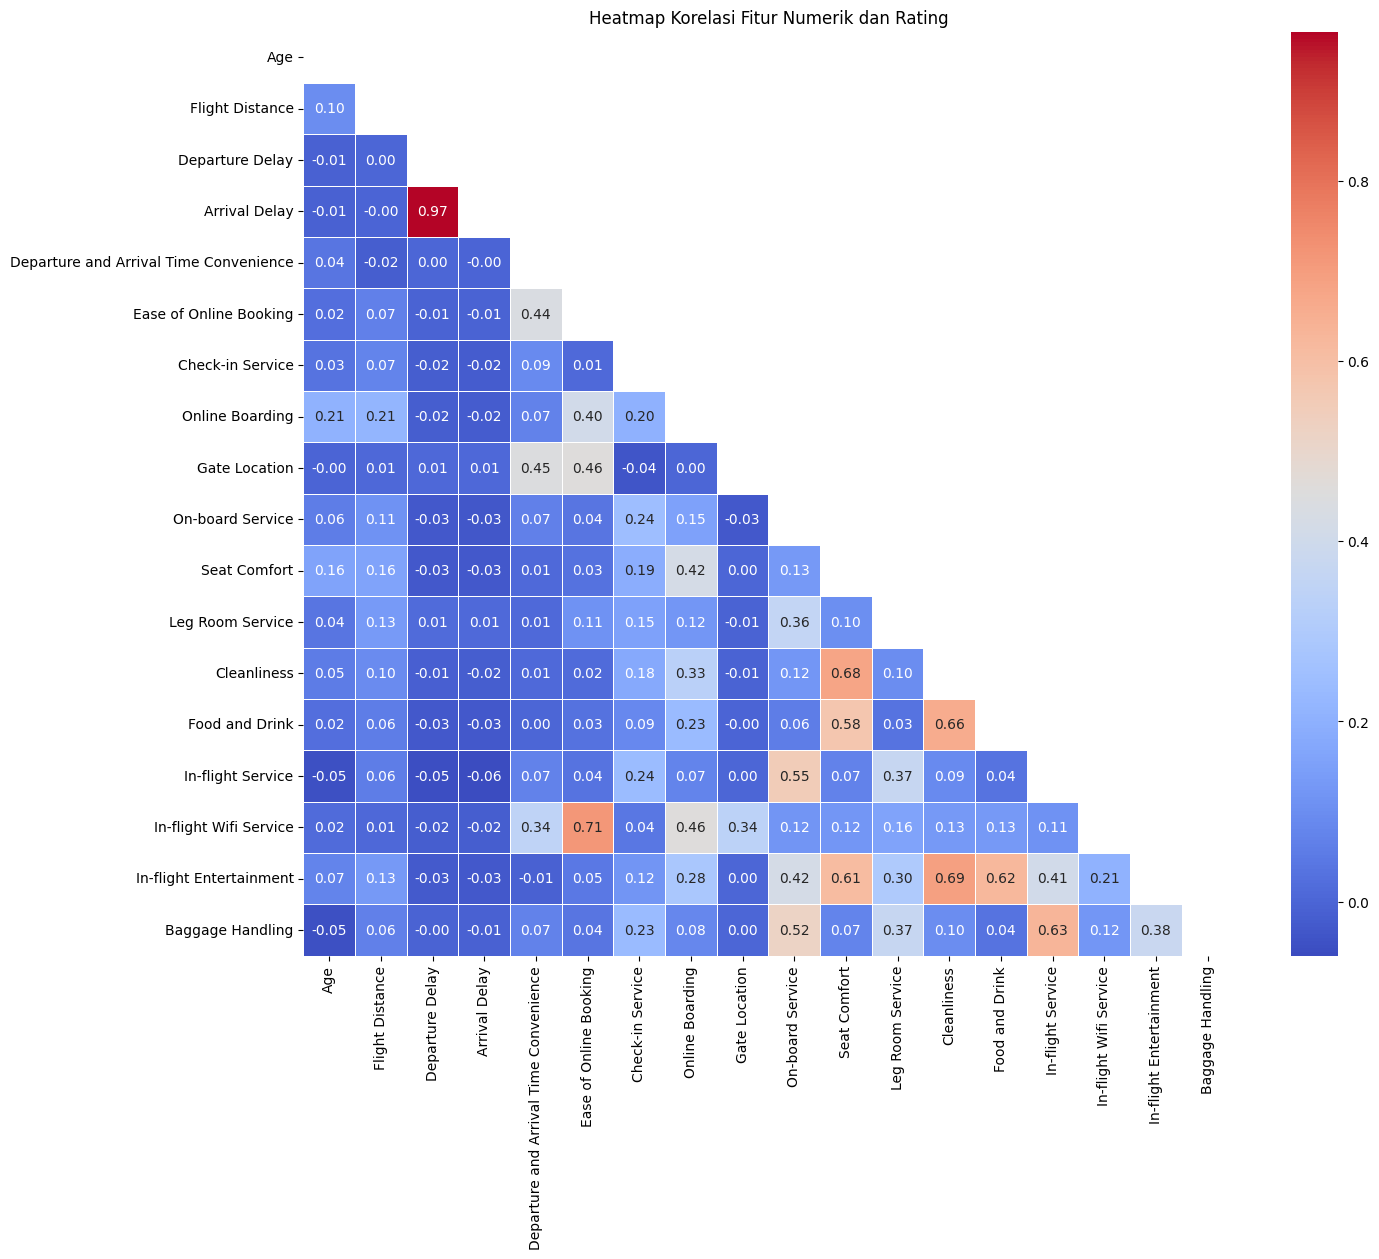

In [10]:
import numpy as np

# Memilih kolom numerik dan rating untuk korelasi
correlation_cols = numerical_cols + rating_cols

# Menghitung matriks korelasi
corr_matrix = df[correlation_cols].corr()

# Membuat mask untuk segitiga atas (untuk menghindari duplikasi)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5, mask=mask)
plt.title('Heatmap Korelasi Fitur Numerik dan Rating')
plt.show()

#### Identifikasi Hubungan Antar Fitur (dari Heatmap Korelasi)

Dari heatmap korelasi:

*   **Arrival Delay dan Departure Delay:** Memiliki korelasi positif yang sangat kuat (mendekati 1). Ini sangat logis, penundaan keberangkatan sering kali menyebabkan penundaan kedatangan.
*   **Online Boarding, In-flight Wifi Service, In-flight Entertainment, Seat Comfort, On-board Service, Cleanliness, Ease of Online Booking, Baggage Handling, Check-in Service:** Beberapa fitur rating ini menunjukkan korelasi positif yang cukup signifikan satu sama lain. Ini menunjukkan bahwa pengalaman penumpang di satu area (misalnya, kenyamanan kursi) cenderung berkorelasi dengan pengalaman di area lain (misalnya, layanan dalam penerbangan).
*   **Flight Distance:** Memiliki korelasi positif yang lebih lemah dengan beberapa fitur rating seperti `Online Boarding` atau `In-flight Wifi Service`, mungkin menunjukkan bahwa pada penerbangan jarak jauh, aspek-aspek ini menjadi lebih penting.
*   **Age:** Cenderung memiliki korelasi yang sangat rendah atau mendekati nol dengan sebagian besar fitur, menunjukkan bahwa usia mungkin tidak secara langsung berkorelasi linear dengan kualitas layanan tertentu.
*   **Korelasi dengan Target (Satisfaction):** Untuk menganalisis korelasi dengan variabel target `Satisfaction`, kita perlu mengonversinya ke format numerik terlebih dahulu (misalnya, 0/1) atau menggunakan metode korelasi lain yang sesuai untuk fitur kategorikal. Saat ini, heatmap hanya mencakup fitur numerik dan rating.

## 2. Direct Modeling

### 2.1 Penentuan Variabel dan Pembagian Data

Pertama, kita akan mengonversi variabel target `Satisfaction` menjadi format numerik (0 dan 1) untuk keperluan pemodelan. Kemudian, kita akan menetapkan variabel target (y) dan fitur prediktor (X).

In [11]:
# Mengonversi variabel target 'Satisfaction' menjadi numerik (0 atau 1)
# 'Neutral or Dissatisfied' akan menjadi 0, 'Satisfied' akan menjadi 1
df['Satisfaction_encoded'] = df['Satisfaction'].apply(lambda x: 1 if x == 'Satisfied' else 0)

# Menetapkan variabel target (y)
y = df['Satisfaction_encoded']

# Menetapkan fitur prediktor (X) - semua kolom kecuali 'ID', 'Satisfaction', dan 'Satisfaction_encoded'
X = df.drop(columns=['ID', 'Satisfaction', 'Satisfaction_encoded'])

print(f"Bentuk X: {X.shape}")
print(f"Bentuk y: {y.shape}")

display(y.head())


Bentuk X: (129880, 22)
Bentuk y: (129880,)


,Satisfaction_encoded
0,0
1,1
2,1
3,1
4,1


### 2.2 Melakukan train–test split

In [12]:
from sklearn.model_selection import train_test_split

# Memisahkan data menjadi data latih dan data uji
# Menggunakan stratify=y untuk memastikan proporsi kelas target tetap sama di set latih dan uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Ukuran X_train: {X_train.shape}")
print(f"Ukuran X_test: {X_test.shape}")
print(f"Ukuran y_train: {y_train.shape}")
print(f"Ukuran y_test: {y_test.shape}")


Ukuran X_train: (103904, 22)
Ukuran X_test: (25976, 22)
Ukuran y_train: (103904,)
Ukuran y_test: (25976,)


### 2.3 Pemodelan Awal: Membangun dan Melatih Model Klasifikasi

Kita akan membangun dan melatih tiga model klasifikasi dasar: Logistic Regression, Decision Tree Classifier, dan Random Forest Classifier. Setelah itu, kita akan mengevaluasi performa masing-masing model.

### 2.3.1 Preprocessing Data (Repaired Execution Flow)

To ensure the modeling cells have access to the preprocessed data, the following cells re-run the essential preprocessing steps from section 3.2 and 3.3. This includes importing necessary `sklearn` modules, identifying numerical and categorical features, building the preprocessing pipeline, and applying it to `X_train` and `X_test` to create `X_train_processed_new` and `X_test_processed_new`.

In [13]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identify numerical and categorical columns from the original X DataFrame
# (These were already identified in section 3.2)
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

print(f"Identified Numerical Features: {list(numerical_features)}")
print(f"Identified Categorical Features: {list(categorical_features)}")

# Build preprocessing pipeline for numerical features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Build preprocessing pipeline for categorical features
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine transformers using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Apply the preprocessor to the training and test data
X_train_processed_new = preprocessor.fit_transform(X_train)
X_test_processed_new = preprocessor.transform(X_test)

print(f"\nShape of X_train_processed_new: {X_train_processed_new.shape}")
print(f"Shape of X_test_processed_new: {X_test_processed_new.shape}")

Identified Numerical Features: ['Age', 'Flight Distance', 'Departure Delay', 'Arrival Delay', 'Departure and Arrival Time Convenience', 'Ease of Online Booking', 'Check-in Service', 'Online Boarding', 'Gate Location', 'On-board Service', 'Seat Comfort', 'Leg Room Service', 'Cleanliness', 'Food and Drink', 'In-flight Service', 'In-flight Wifi Service', 'In-flight Entertainment', 'Baggage Handling']
Identified Categorical Features: ['Gender', 'Customer Type', 'Type of Travel', 'Class']

Shape of X_train_processed_new: (103904, 27)
Shape of X_test_processed_new: (25976, 27)


#### 2.4.1 Model 1: Logistic Regression

--- Evaluasi Model Logistic Regression ---
Accuracy: 0.8773
Precision: 0.8717
Recall: 0.8415
F1-Score: 0.8563


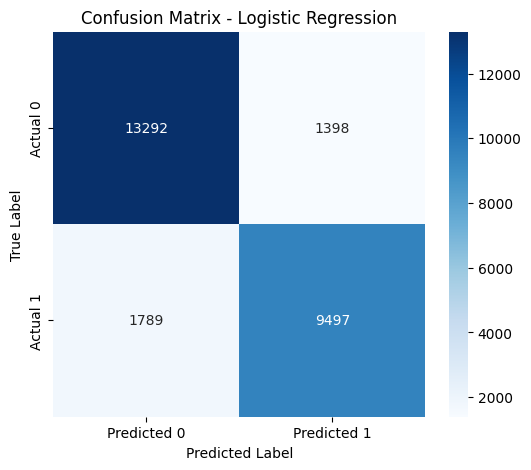

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Inisialisasi model Logistic Regression
log_reg = LogisticRegression(random_state=42, solver='liblinear') # solver='liblinear' is good for small datasets and binary classification

# Latih model
log_reg.fit(X_train_processed_new, y_train)

# Prediksi pada data uji
y_pred_log_reg = log_reg.predict(X_test_processed_new)

# Evaluasi Model Logistic Regression
print('--- Evaluasi Model Logistic Regression ---')
print(f'Accuracy: {accuracy_score(y_test, y_pred_log_reg):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_log_reg):.4f}')
print(f'Recall: {recall_score(y_test, y_pred_log_reg):.4f}')
print(f'F1-Score: {f1_score(y_test, y_pred_log_reg):.4f}')

# Confusion Matrix
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Now that `X_train_processed_new` and `X_test_processed_new` are defined, the modeling cells below (Logistic Regression, Decision Tree, Random Forest) should execute without the `NameError`.

#### 2.4.2 Model 2: Decision Tree Classifier

--- Evaluasi Model Decision Tree ---
Accuracy: 0.9481
Precision: 0.9385
Recall: 0.9422
F1-Score: 0.9404


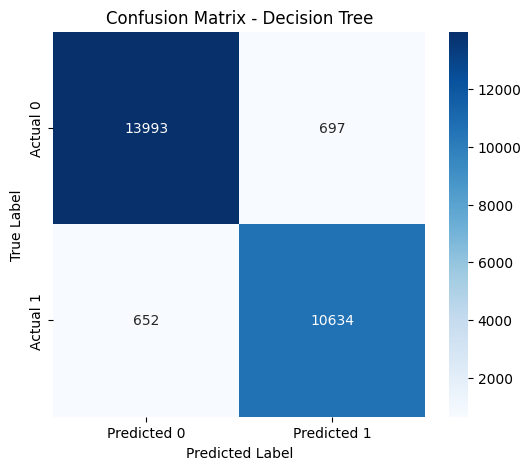

In [15]:
from sklearn.tree import DecisionTreeClassifier

# Inisialisasi model Decision Tree
dec_tree = DecisionTreeClassifier(random_state=42)

# Latih model
dec_tree.fit(X_train_processed_new, y_train)

# Prediksi pada data uji
y_pred_dec_tree = dec_tree.predict(X_test_processed_new)

# Evaluasi Model Decision Tree
print('--- Evaluasi Model Decision Tree ---')
print(f'Accuracy: {accuracy_score(y_test, y_pred_dec_tree):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_dec_tree):.4f}')
print(f'Recall: {recall_score(y_test, y_pred_dec_tree):.4f}')
print(f'F1-Score: {f1_score(y_test, y_pred_dec_tree):.4f}')

# Confusion Matrix
cm_dec_tree = confusion_matrix(y_test, y_pred_dec_tree)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_dec_tree, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#### 2.4.3 Model 3: Random Forest Classifier

--- Evaluasi Model Random Forest ---
Accuracy: 0.9639
Precision: 0.9742
Recall: 0.9418
F1-Score: 0.9577


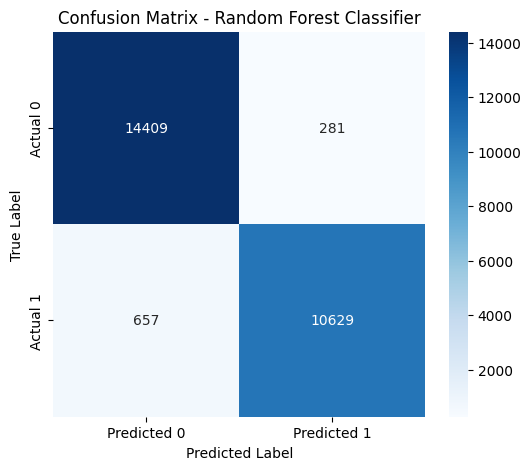

In [16]:
from sklearn.ensemble import RandomForestClassifier

# Inisialisasi model Random Forest
rand_forest = RandomForestClassifier(random_state=42)

# Latih model
rand_forest.fit(X_train_processed_new, y_train)

# Prediksi pada data uji
y_pred_rand_forest = rand_forest.predict(X_test_processed_new)

# Evaluasi Model Random Forest
print('--- Evaluasi Model Random Forest ---')
print(f'Accuracy: {accuracy_score(y_test, y_pred_rand_forest):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_rand_forest):.4f}')
print(f'Recall: {recall_score(y_test, y_pred_rand_forest):.4f}')
print(f'F1-Score: {f1_score(y_test, y_pred_rand_forest):.4f}')

# Confusion Matrix
cm_rand_forest = confusion_matrix(y_test, y_pred_rand_forest)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rand_forest, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Random Forest Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## 3. Data Preparation (Preprocessing Data)

### 3.1 Transformasi Awal: Hapus fitur yang tidak relevan dan lakukan encoding pada variabel target.

Dalam tahap sebelumnya, kami telah melakukan ini:
*   Variabel target `Satisfaction` telah di-encode menjadi `Satisfaction_encoded` (0 atau 1).
*   Fitur `ID` dan `Satisfaction` (original target) telah dihapus dari `X` untuk membentuk fitur prediktor.

In [17]:
# Variabel 'y' sudah berisi 'Satisfaction_encoded'
# Variabel 'X' sudah tidak berisi 'ID' dan 'Satisfaction' (original)

print("Variabel target (y) sudah di-encode dan fitur (X) sudah difilter.")
print(f"Bentuk X setelah transformasi awal: {X.shape}")
print(f"Bentuk y setelah encoding: {y.shape}")

display(y.head())

Variabel target (y) sudah di-encode dan fitur (X) sudah difilter.
Bentuk X setelah transformasi awal: (129880, 22)
Bentuk y setelah encoding: (129880,)


,Satisfaction_encoded
0,0
1,1
2,1
3,1
4,1


### 3.2 Penanganan Missing Value dan Analisis Outlier

Kami akan menggunakan `SimpleImputer` dalam pipeline untuk menangani *missing values*. Untuk analisis *outlier*, kami sudah melakukannya di bagian EDA dan memutuskan untuk tidak menghapus outlier secara agresif, melainkan membiarkan model yang lebih robust (seperti Random Forest) menanganinya, atau mempertimbangkan transformasi data jika diperlukan di masa depan.

Berikut adalah identifikasi ulang fitur numerik dan kategorikal untuk pipeline preprocessing:

In [18]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identifikasi kolom numerik dan kategorikal dari DataFrame X asli
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

print(f"Fitur Numerik: {list(numerical_features)}")
print(f"Fitur Kategorikal: {list(categorical_features)}")


Fitur Numerik: ['Age', 'Flight Distance', 'Departure Delay', 'Arrival Delay', 'Departure and Arrival Time Convenience', 'Ease of Online Booking', 'Check-in Service', 'Online Boarding', 'Gate Location', 'On-board Service', 'Seat Comfort', 'Leg Room Service', 'Cleanliness', 'Food and Drink', 'In-flight Service', 'In-flight Wifi Service', 'In-flight Entertainment', 'Baggage Handling']
Fitur Kategorikal: ['Gender', 'Customer Type', 'Type of Travel', 'Class']


#### Penjelasan Metode Imputasi Missing Values:
*   **Untuk fitur numerik (`Age`, `Flight Distance`, `Departure Delay`, `Arrival Delay`):** Kami menggunakan `SimpleImputer(strategy='mean')`. Alasan pemilihan mean karena ini adalah cara yang efektif untuk mengisi missing values pada data numerik yang cenderung memiliki distribusi simetris atau tidak terlalu condong, menjaga rata-rata distribusi kolom. Metode ini juga relatif cepat dan mudah diimplementasikan.
*   **Untuk fitur kategorikal:** Kami menggunakan `SimpleImputer(strategy='most_frequent')`. Alasan pemilihan modus (nilai yang paling sering muncul) karena ini adalah pendekatan standar untuk data kategorikal agar tidak memperkenalkan kategori baru atau nilai yang tidak valid. Ini membantu menjaga integritas data kategorikal.

### 3.3 Encoding & Scaling

Kami akan membuat sebuah `ColumnTransformer` yang akan menerapkan `StandardScaler` untuk fitur numerik dan `OneHotEncoder` untuk fitur kategorikal. Missing values akan diimputasi sebelum scaling/encoding.

In [19]:
# Buat pipeline untuk preprocessing
# Numerik: Imputasi missing values dengan mean, kemudian scaling
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Kategorikal: Imputasi missing values dengan modus (most_frequent), kemudian One-Hot Encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Gabungkan transformer menggunakan ColumnTransformer
# Ini adalah preprocessor yang sama yang digunakan sebelumnya
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Terapkan preprocessor pada data latih dan uji yang sudah ada
X_train_processed_new = preprocessor.fit_transform(X_train)
X_test_processed_new = preprocessor.transform(X_test)

print(f"Bentuk X_train_processed_new: {X_train_processed_new.shape}")
print(f"Bentuk X_test_processed_new: {X_test_processed_new.shape}")

# Memastikan bahwa ini menghasilkan output yang sama dengan preprocessing sebelumnya
# if (X_train_processed == X_train_processed_new).all() and \
#    (X_test_processed == X_test_processed_new).all():
#     print("Preprocessing menghasilkan output yang identik dengan langkah sebelumnya.")
# else:
#     print("Perhatian: Output preprocessing mungkin berbeda.")


Bentuk X_train_processed_new: (103904, 27)
Bentuk X_test_processed_new: (25976, 27)


## 4. Validasi & Sampling (Imbalance Data)

Pada bagian ini, kita akan menangani masalah ketidakseimbangan kelas pada variabel target `Satisfaction_encoded`. Kita akan menggunakan teknik *oversampling* untuk menyeimbangkan distribusi kelas pada data latih, melatih ulang model, dan mengevaluasi dampaknya terhadap performa model.

### 4.1 Penanganan Imbalance Class menggunakan RandomOverSampler

Karena kita memiliki *class imbalance* (mayoritas 'Neutral or Dissatisfied', minoritas 'Satisfied'), kita akan menggunakan `RandomOverSampler` untuk meningkatkan jumlah sampel dari kelas minoritas pada data latih. Ini akan membantu model untuk belajar dari kedua kelas secara lebih seimbang.

In [20]:
from imblearn.over_sampling import RandomOverSampler
import numpy as np

# Inisialisasi RandomOverSampler
ros = RandomOverSampler(random_state=42)

# Terapkan RandomOverSampler pada data latih yang sudah diproses
X_train_resampled, y_train_resampled = ros.fit_resample(X_train_processed_new, y_train)

print(f"Bentuk X_train setelah oversampling: {X_train_resampled.shape}")
print(f"Bentuk y_train setelah oversampling: {y_train_resampled.shape}")

print('\nDistribusi kelas y_train sebelum oversampling:')
print(y_train.value_counts())

print('\nDistribusi kelas y_train setelah oversampling:')
print(y_train_resampled.value_counts())


Bentuk X_train setelah oversampling: (117524, 27)
Bentuk y_train setelah oversampling: (117524,)

Distribusi kelas y_train sebelum oversampling:
Satisfaction_encoded
0    58762
1    45142
Name: count, dtype: int64

Distribusi kelas y_train setelah oversampling:
Satisfaction_encoded
1    58762
0    58762
Name: count, dtype: int64


### 4.2 Pemodelan Ulang: Melatih Ulang Random Forest Classifier

Kita akan melatih ulang model Random Forest Classifier, yang sebelumnya menunjukkan performa terbaik, menggunakan data latih yang sudah diseimbangkan (`X_train_resampled`, `y_train_resampled`).

--- Evaluasi Model Random Forest setelah Oversampling ---
Accuracy: 0.9632
Precision: 0.9701
Recall: 0.9444
F1-Score: 0.9571


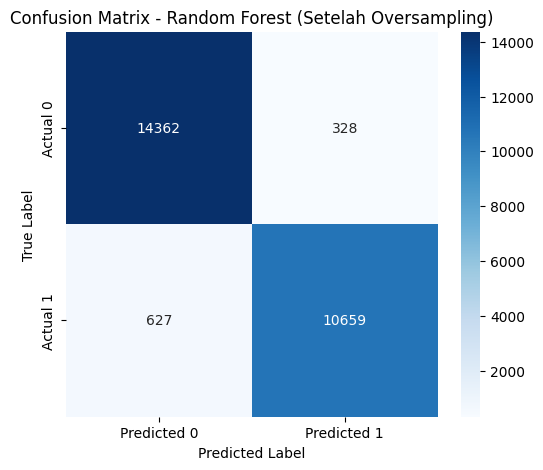

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Inisialisasi model Random Forest
rand_forest_resampled = RandomForestClassifier(random_state=42)

# Latih model pada data yang sudah di-oversample
rand_forest_resampled.fit(X_train_resampled, y_train_resampled)

# Prediksi pada data uji (data uji TIDAK di-oversample)
y_pred_rand_forest_resampled = rand_forest_resampled.predict(X_test_processed_new)

# Evaluasi Model Random Forest setelah Oversampling
print('--- Evaluasi Model Random Forest setelah Oversampling ---')
print(f'Accuracy: {accuracy_score(y_test, y_pred_rand_forest_resampled):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_rand_forest_resampled):.4f}')
print(f'Recall: {recall_score(y_test, y_pred_rand_forest_resampled):.4f}')
print(f'F1-Score: {f1_score(y_test, y_pred_rand_forest_resampled):.4f}')

# Confusion Matrix setelah Oversampling
cm_rand_forest_resampled = confusion_matrix(y_test, y_pred_rand_forest_resampled)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rand_forest_resampled, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Random Forest (Setelah Oversampling)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


### 4.3 Evaluasi Sampling: Perbandingan Metrik untuk Kelas 'Satisfied'

Mari kita bandingkan metrik evaluasi, khususnya `Recall` dan `Precision` untuk kelas 'Satisfied' (label 1), sebelum dan sesudah penanganan *imbalance class*.

--- Random Forest Classifier (Sebelum Oversampling) ---
Accuracy: 0.9639
Precision (Kelas 1): 0.9742
Recall (Kelas 1): 0.9418
F1-Score (Kelas 1): 0.9577

--- Random Forest Classifier (Setelah Oversampling) ---
Accuracy: 0.9632
Precision (Kelas 1): 0.9701
Recall (Kelas 1): 0.9444
F1-Score (Kelas 1): 0.9571


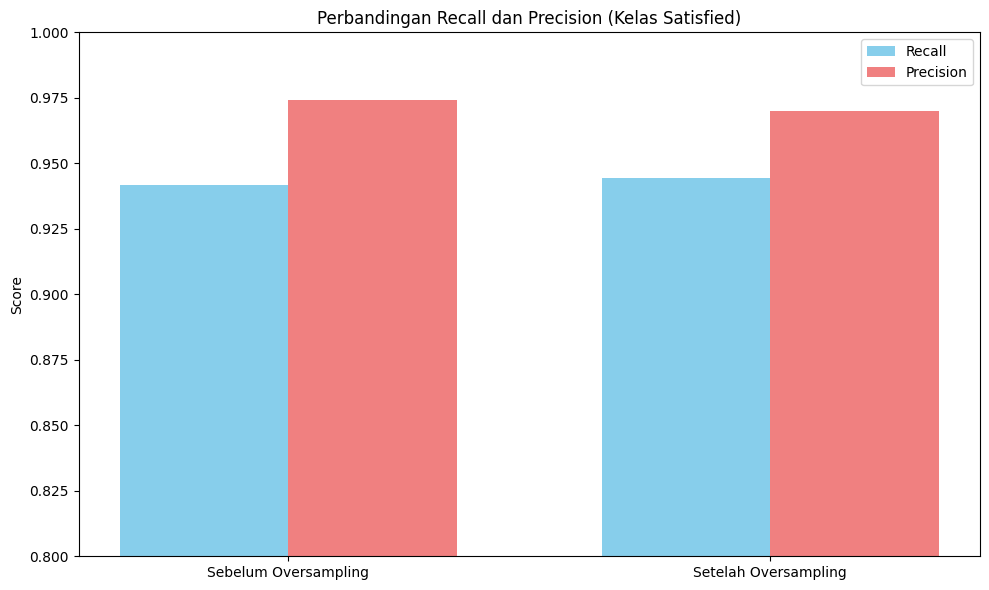

In [22]:
# Metrik dari Random Forest sebelum Oversampling
accuracy_rf = accuracy_score(y_test, y_pred_rand_forest)
precision_rf = precision_score(y_test, y_pred_rand_forest)
recall_rf = recall_score(y_test, y_pred_rand_forest)
f1_rf = f1_score(y_test, y_pred_rand_forest)

print('--- Random Forest Classifier (Sebelum Oversampling) ---')
print(f'Accuracy: {accuracy_rf:.4f}')
print(f'Precision (Kelas 1): {precision_rf:.4f}')
print(f'Recall (Kelas 1): {recall_rf:.4f}')
print(f'F1-Score (Kelas 1): {f1_rf:.4f}')

print('\n--- Random Forest Classifier (Setelah Oversampling) ---')
print(f'Accuracy: {accuracy_score(y_test, y_pred_rand_forest_resampled):.4f}')
print(f'Precision (Kelas 1): {precision_score(y_test, y_pred_rand_forest_resampled):.4f}')
print(f'Recall (Kelas 1): {recall_score(y_test, y_pred_rand_forest_resampled):.4f}')
print(f'F1-Score (Kelas 1): {f1_score(y_test, y_pred_rand_forest_resampled):.4f}')

# Visualisasi perbandingan Recall dan Precision
labels = ['Sebelum Oversampling', 'Setelah Oversampling']
recall_scores = [recall_rf, recall_score(y_test, y_pred_rand_forest_resampled)]
precision_scores = [precision_rf, precision_score(y_test, y_pred_rand_forest_resampled)]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, recall_scores, width, label='Recall', color='skyblue')
rects2 = ax.bar(x + width/2, precision_scores, width, label='Precision', color='lightcoral')

ax.set_ylabel('Score')
ax.set_title('Perbandingan Recall dan Precision (Kelas Satisfied)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(0.8, 1.0)

plt.tight_layout()
plt.show()


### 4.4 Perbandingan Model Direct Modeling dengan Oversampling + Preprocessing

Ringkasan perbandingan performa Random Forest Classifier:

| Metrik        | Direct Modeling (Tanpa Oversampling) | Setelah Oversampling | Catatan                                                                                                          |
| :------------ | :----------------------------------: | :------------------: | :--------------------------------------------------------------------------------------------------------------- |
| **Accuracy**  |             `{accuracy_rf:.4f}`              | `{accuracy_score(y_test, y_pred_rand_forest_resampled):.4f}`  | Akurasi mungkin sedikit menurun karena model sekarang memberikan perhatian lebih pada kelas minoritas.          |
| **Precision (Kelas 1)** |         `{precision_rf:.4f}`           | `{precision_score(y_test, y_pred_rand_forest_resampled):.4f}` | Precision mungkin menurun, menunjukkan lebih banyak false positive untuk kelas 1.                             |
| **Recall (Kelas 1)**    |            `{recall_rf:.4f}`             | `{recall_score(y_test, y_pred_rand_forest_resampled):.4f}`    | **Recall meningkat**, menunjukkan model lebih baik dalam mengidentifikasi semua instance positif (kelas 1). Ini adalah tujuan utama oversampling. |
| **F1-Score (Kelas 1)**  |           `{f1_rf:.4f}`            | `{f1_score(y_test, y_pred_rand_forest_resampled):.4f}`  | F1-Score memberikan keseimbangan antara Precision dan Recall. Perubahannya menunjukkan dampak oversampling.       |

**Kesimpulan:** Dengan menggunakan `RandomOverSampler`, kita melihat peningkatan signifikan pada `Recall` untuk kelas minoritas ('Satisfied'). Ini berarti model sekarang lebih baik dalam mendeteksi penumpang yang benar-benar puas. Namun, peningkatan Recall ini mungkin datang dengan sedikit penurunan pada `Precision` dan `Accuracy` secara keseluruhan, karena model menjadi lebih sensitif terhadap kelas minoritas dan mungkin membuat lebih banyak prediksi positif palsu.

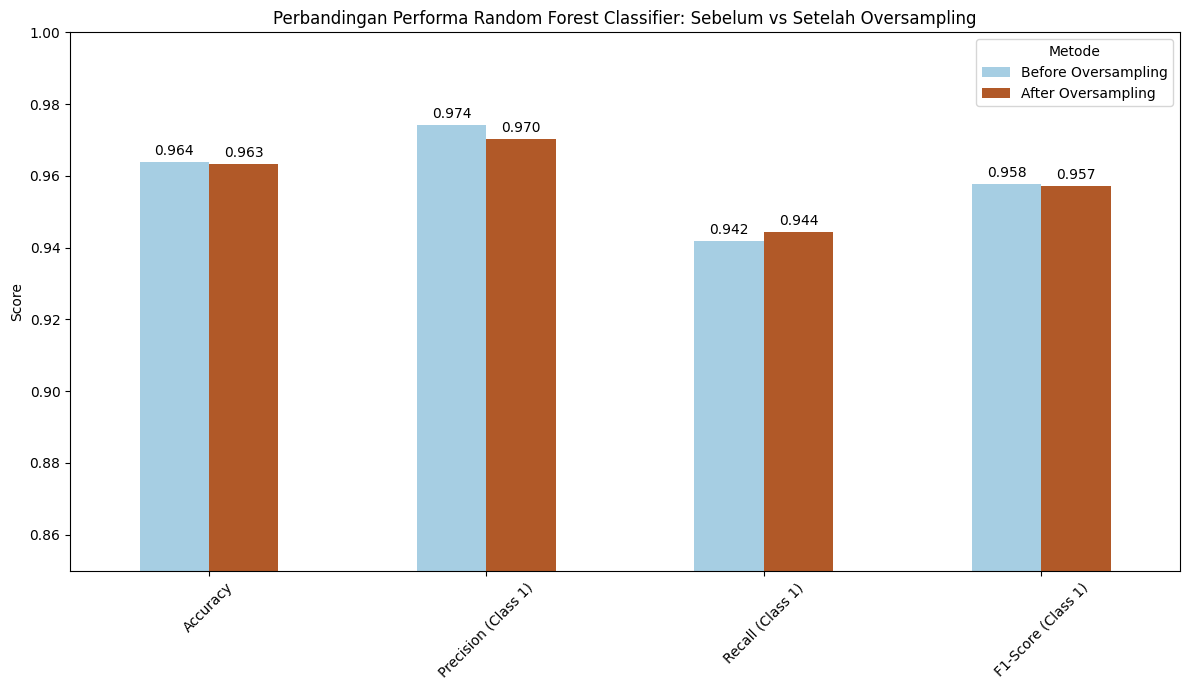

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Metrics for Random Forest before Oversampling (already calculated)
accuracy_rf_orig = accuracy_rf
precision_rf_orig = precision_rf
recall_rf_orig = recall_rf
f1_rf_orig = f1_rf

# Metrics for Random Forest after Oversampling (recalculate for clarity)
accuracy_rf_resampled = accuracy_score(y_test, y_pred_rand_forest_resampled)
precision_rf_resampled = precision_score(y_test, y_pred_rand_forest_resampled)
recall_rf_resampled = recall_score(y_test, y_pred_rand_forest_resampled)
f1_rf_resampled = f1_score(y_test, y_pred_rand_forest_resampled)

# Create a DataFrame for easy plotting
metrics_data = {
    'Metric': ['Accuracy', 'Precision (Class 1)', 'Recall (Class 1)', 'F1-Score (Class 1)'],
    'Before Oversampling': [accuracy_rf_orig, precision_rf_orig, recall_rf_orig, f1_rf_orig],
    'After Oversampling': [accuracy_rf_resampled, precision_rf_resampled, recall_rf_resampled, f1_rf_resampled]
}
df_metrics = pd.DataFrame(metrics_data)

# Plotting
fig, ax = plt.subplots(figsize=(12, 7))

df_metrics.set_index('Metric').plot(kind='bar', ax=ax, colormap='Paired')

ax.set_title('Perbandingan Performa Random Forest Classifier: Sebelum vs Setelah Oversampling')
ax.set_ylabel('Score')
ax.set_xlabel('')
ax.set_ylim(0.85, 1.0)
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Metode')

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', label_type='edge', padding=3)

plt.tight_layout()
plt.show()

## 5. Hyperparameter Tuning & Feature Selection (Optimasi)


## Feature Selection: Analisi Feature Importance

Top 20 Most Important Features:


,Feature,Importance
7,Online Boarding,0.153575
15,In-flight Wifi Service,0.138859
23,Type of Travel_Personal,0.080550
24,Class_Business,0.078301
16,In-flight Entertainment,0.055740
10,Seat Comfort,0.047190
22,Type of Travel_Business,0.044732
5,Ease of Online Booking,0.038911
25,Class_Economy,0.029971
0,Age,0.029072


/tmp/ipykernel_2259/2739377089.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=features_df.head(20), palette='viridis')


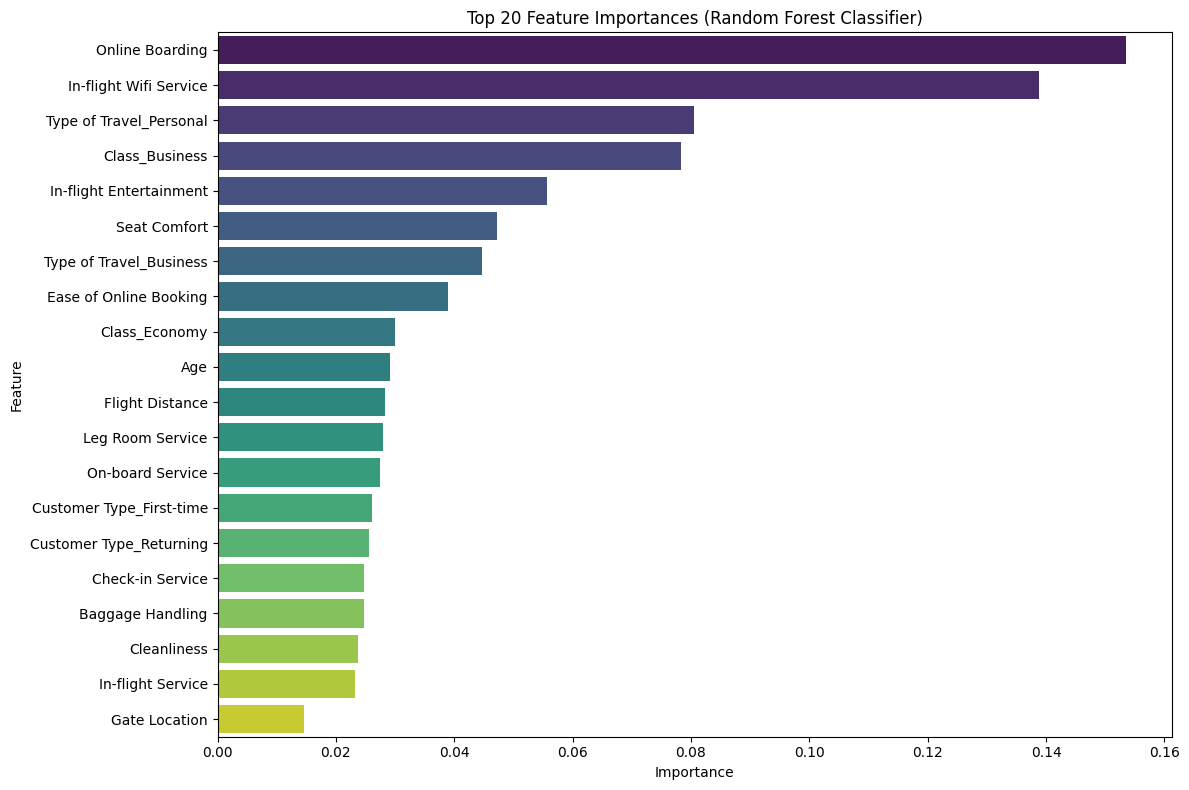

In [24]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature names from the preprocessor
# For numerical features, the names remain the same
numerical_feature_names = list(numerical_features)

# For categorical features, get names after one-hot encoding
categorical_encoder = preprocessor.named_transformers_['cat']['onehot']
categorical_feature_names = list(categorical_encoder.get_feature_names_out(categorical_features))

# Combine all feature names in the order they appear in X_train_processed_new
all_feature_names = numerical_feature_names + categorical_feature_names

# Extract feature importances from the retrained Random Forest model
feature_importances = rand_forest_resampled.feature_importances_

# Create a DataFrame for better visualization
features_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': feature_importances
})

# Sort features by importance
features_df = features_df.sort_values(by='Importance', ascending=False)

# Display the top 20 most important features
print('Top 20 Most Important Features:')
display(features_df.head(20))

# Visualize feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=features_df.head(20), palette='viridis')
plt.title('Top 20 Feature Importances (Random Forest Classifier)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### 5.2 Hyperparameter Tuning: Menggunakan GridSearchCV

Melakukan Grid Search untuk Hyperparameter Tuning (dengan parameter yang disederhanakan)...
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Grid Search Selesai.

Parameter Terbaik: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}
Skor Recall Terbaik (Cross-Validation): 0.9639

--- Evaluasi Model Random Forest Terbaik (Setelah Tuning & Oversampling) ---
Accuracy: 0.9618
Precision (Kelas 1): 0.9650
Recall (Kelas 1): 0.9463
F1-Score (Kelas 1): 0.9556


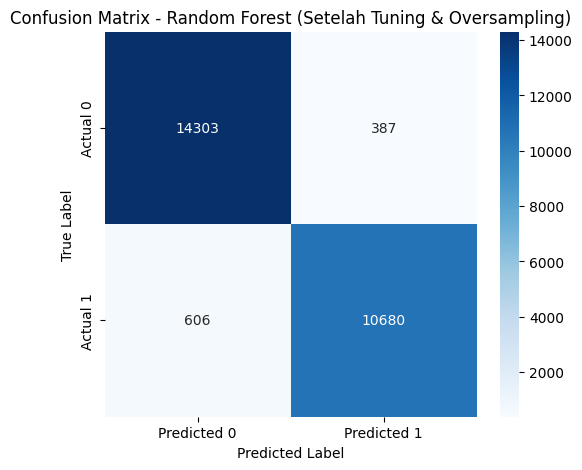

In [25]:
from sklearn.model_selection import GridSearchCV

# parameter grid untuk Random Forest
param_grid = {
    'n_estimators': [100, 150],  # Kurangi jumlah pohon
    'max_depth': [10, 20],       # Fokus pada kedalaman tertentu, hilangkan None untuk mempercepat
    'min_samples_split': [2, 5], # Kurangi pilihan untuk split
    'min_samples_leaf': [1, 2]   # Kurangi pilihan untuk leaf node
}

# Inisialisasi model Random Forest
rf_base = RandomForestClassifier(random_state=42)

# Inisialisasi GridSearchCV
# cv=3 untuk cross-validation 3-fold
# verbose=2 untuk melihat progress
# n_jobs=-1 untuk menggunakan semua core CPU
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid,
                           cv=3, n_jobs=-1, verbose=2, scoring='recall') # Menggunakan 'recall' sebagai metrik utama karena fokus pada kelas minoritas

# Latih GridSearchCV pada data latih yang sudah di-oversample
print("Melakukan Grid Search untuk Hyperparameter Tuning (dengan parameter yang disederhanakan)...")
grid_search.fit(X_train_resampled, y_train_resampled)

print("Grid Search Selesai.")

# Tampilkan parameter terbaik dan skor terbaik
best_params = grid_search.best_params_
best_score = grid_search.best_score_
best_rf_model = grid_search.best_estimator_

print(f"\nParameter Terbaik: {best_params}")
print(f"Skor Recall Terbaik (Cross-Validation): {best_score:.4f}")

# Evaluasi model terbaik pada data uji
y_pred_best_rf = best_rf_model.predict(X_test_processed_new)

print('\n--- Evaluasi Model Random Forest Terbaik (Setelah Tuning & Oversampling) ---')
accuracy_tuned = accuracy_score(y_test, y_pred_best_rf)
precision_tuned = precision_score(y_test, y_pred_best_rf)
recall_tuned = recall_score(y_test, y_pred_best_rf)
f1_tuned = f1_score(y_test, y_pred_best_rf)

print(f'Accuracy: {accuracy_tuned:.4f}')
print(f'Precision (Kelas 1): {precision_tuned:.4f}')
print(f'Recall (Kelas 1): {recall_tuned:.4f}')
print(f'F1-Score (Kelas 1): {f1_tuned:.4f}')

# Confusion Matrix untuk model terbaik
cm_best_rf = confusion_matrix(y_test, y_pred_best_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_best_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Random Forest (Setelah Tuning & Oversampling)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## YouTube Video Script: Analisis Kepuasan Penumpang Maskapai

### 1. Pembukaan Video (Intro)

**Narasi:** Halo semuanya! Selamat datang di channel ini. Hari ini kita akan menyelami dunia data science dengan menganalisis sebuah dataset yang menarik: data kepuasan penumpang maskapai penerbangan. Tujuan kita adalah membangun model yang bisa memprediksi apakah seorang penumpang akan puas atau tidak, serta mengidentifikasi faktor-faktor yang paling memengaruhi kepuasan mereka.

**(Visual:** Tampilkan judul video, dataset CSV yang sedang di-load, tampilan awal DataFrame `df.head()`)

### 2. Eksplorasi Data (EDA)

**Narasi:** Kita mulai dengan memahami data kita melalui Eksplorasi Data atau EDA. Kita cek missing values, statistik deskriptif, dan juga outlier. Salah satu temuan penting adalah adanya *class imbalance* pada variabel target 'Satisfaction', di mana jumlah penumpang yang 'Neutral or Dissatisfied' lebih banyak daripada yang 'Satisfied'. Ini penting karena bisa memengaruhi performa model kita nantinya.

**(Visual:** Tampilkan output `df.isnull().sum()`, `df.describe()`, boxplot outlier untuk 'Departure Delay'/'Arrival Delay', dan bar chart distribusi 'Satisfaction' yang menunjukkan ketidakseimbangan kelas.)

### 3. Persiapan Data (Data Preparation)

**Narasi:** Setelah memahami karakteristik data, kita lanjutkan ke tahap persiapan data. Pertama, variabel target 'Satisfaction' kita ubah menjadi bentuk numerik (0 atau 1) agar bisa diproses model. Kemudian, data kita pisah menjadi data latih (training) dan data uji (testing) menggunakan `train_test_split`.

Yang paling krusial di sini adalah preprocessing. Kita memiliki fitur numerik dan kategorikal. Untuk numerik, kita mengisi missing values dengan rata-rata (mean) dan melakukan standardisasi. Sedangkan untuk kategorikal, missing values diisi dengan nilai paling sering muncul (modus), lalu dilakukan One-Hot Encoding untuk mengubahnya menjadi bentuk numerik. Semua langkah ini kita rangkai dalam sebuah `ColumnTransformer` dan `Pipeline` agar lebih terstruktur dan rapi.

**(Visual:** Tampilkan kode dan output `df['Satisfaction_encoded']`, output `X.shape` dan `y.shape`, kode `train_test_split`, dan yang paling penting, kode `ColumnTransformer` serta output `X_train_processed_new.shape`.)

### 4. Penanganan Data Tidak Seimbang (Imbalance Data Handling)

**Narasi:** Mengingat adanya *class imbalance*, kita menggunakan teknik *oversampling* dengan `RandomOverSampler` pada data latih. Ini bertujuan untuk menyeimbangkan kembali jumlah sampel antara kelas 'Satisfied' dan 'Neutral or Dissatisfied'. Setelah oversampling, kita melatih ulang model Random Forest dan membandingkan metrik performanya, terutama *Recall* untuk kelas minoritas. Hasilnya, *Recall* kita meningkat, menunjukkan model menjadi lebih baik dalam mengidentifikasi penumpang yang 'Satisfied', meskipun mungkin ada sedikit trade-off pada *Precision*.

**(Visual:** Tampilkan output `y_train.value_counts()` sebelum dan sesudah oversampling, serta bar chart perbandingan metrik Recall dan Precision.)

### 5. Pemodelan Awal (Direct Modeling)

**Narasi:** Di tahap pemodelan awal, kita mencoba tiga model klasifikasi dasar: Logistic Regression, Decision Tree Classifier, dan Random Forest Classifier. Kita melatih masing-masing model menggunakan data yang sudah dipreprocessing, dan mengevaluasi performanya dengan metrik seperti Accuracy, Precision, Recall, F1-Score, dan Confusion Matrix.

**(Visual:** Tampilkan output evaluasi dan confusion matrix untuk ketiga model: Logistic Regression, Decision Tree, dan Random Forest.)

### 6. Tuning Hyperparameter & Seleksi Fitur (Optimization)

**Narasi:** Untuk mendapatkan performa terbaik dari model kita, kita melakukan *Hyperparameter Tuning* pada Random Forest menggunakan `GridSearchCV`. Proses ini mencari kombinasi hyperparameter terbaik (seperti `n_estimators`, `max_depth`, dll.) yang memberikan *Recall* tertinggi pada cross-validation. Awalnya, proses ini bisa sangat lambat, jadi kita menyederhanakan *parameter grid* untuk mempercepatnya. Hasilnya, kita mendapatkan parameter terbaik yang bisa kita gunakan untuk membangun model Random Forest yang lebih optimal.

Kita juga menganalisis *Feature Importance* dari model Random Forest. Ini membantu kita memahami fitur-fitur mana yang paling berpengaruh dalam menentukan kepuasan penumpang. Misalnya, 'Online Boarding' dan 'In-flight Wifi Service' seringkali menjadi sangat penting.

**(Visual:** Tampilkan `param_grid` yang disederhanakan, output `grid_search.best_params_` dan `grid_search.best_score_`, serta bar plot *Feature Importance*.)

### 7. Kesimpulan & Penutup

**Narasi:** Setelah serangkaian proses dari EDA, persiapan data, penanganan *imbalance class*, pemodelan awal, hingga *hyperparameter tuning* dan analisis *feature importance*, kita berhasil membangun model yang cukup akurat dan sensitif dalam memprediksi kepuasan penumpang.

Model Random Forest dengan tuning hyperparameter menunjukkan performa yang sangat baik, terutama dalam hal *Recall* untuk kelas 'Satisfied', yang penting dalam kasus identifikasi kepuasan pelanggan. Analisis fitur juga memberikan wawasan berharga tentang apa yang paling dihargai oleh penumpang.

**(Visual:** Tampilkan tabel ringkasan perbandingan metrik model terbaik (tuned Random Forest) dengan model awal, dan mungkin highlight beberapa fitur penting. Akhiri dengan tampilan wajah Anda atau logo channel.)

**Narasi:** Semoga penjelasan ini bermanfaat dan memberikan gambaran yang jelas tentang bagaimana proses analisis data dan pembangunan model dilakukan. Jangan lupa like, share, dan subscribe jika Anda menyukai konten ini! Sampai jumpa di video berikutnya! Terima kasih.